# Нейронная сеть прямого распространения (классификация)

## Теория

**Нейронная сеть прямого распространения** (feedforward neural network, многослойный перцептрон, MLP) — это архитектура, в которой данные передаются последовательно через слои нейронов, каждый из которых применяет линейное преобразование и функцию активации. Связи идут строго в одном направлении — от входного слоя к выходному, без циклов.

### Архитектура

Сеть состоит из трёх типов слоёв:

- **Входной слой** (input layer) — принимает исходные признаки объекта.
- **Скрытые слои** (hidden layers) — промежуточные слои, обучающиеся извлекать признаки высокого уровня.
- **Выходной слой** (output layer) — формирует финальное предсказание (например, вероятности классов).

### Прямой проход (Forward Pass)

На каждом слое $l$ вычисляются:

1. **Линейная комбинация** входов:
$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}$$

2. **Активация** — применение нелинейной функции:
$$a^{(l)} = \sigma(z^{(l)})$$

где $W^{(l)}$ — матрица весов, $b^{(l)}$ — вектор смещений, $a^{(l-1)}$ — активации предыдущего слоя.

### Функции активации

| Функция | Формула | Применение |
|---|---|---|
| **ReLU** | $\max(0, x)$ | Скрытые слои; быстро обучается, нет проблемы затухания градиентов |
| **Sigmoid** | $\dfrac{1}{1+e^{-x}}$ | Выходной слой при бинарной классификации |
| **tanh** | $\dfrac{e^x - e^{-x}}{e^x + e^{-x}}$ | Скрытые слои; выход в диапазоне $(-1, 1)$ |
| **Softmax** | $\dfrac{e^{z_i}}{\sum_j e^{z_j}}$ | Выходной слой при многоклассовой классификации; сумма вероятностей равна 1 |

### Функция потерь

Для многоклассовой классификации используется **кросс-энтропия**:

$$L = -\sum_i y_i \log(\hat{y}_i)$$

где $y_i$ — истинная метка (one-hot encoding), $\hat{y}_i$ — предсказанная вероятность класса $i$.

### Обратное распространение ошибки (Backpropagation)

Алгоритм вычисляет **градиент функции потерь** по всем весам сети с помощью правила дифференцирования сложной функции. Градиенты распространяются от выходного слоя к входному. Затем веса обновляются методом **градиентного спуска**:

$$W^{(l)} \leftarrow W^{(l)} - \eta \cdot \frac{\partial L}{\partial W^{(l)}}$$

где $\eta$ — скорость обучения (learning rate).

### Ключевые гиперпараметры MLPClassifier

| Параметр | Значение по умолчанию | Описание |
|---|---|---|
| **hidden_layer_sizes** | `(100,)` | Количество нейронов в каждом скрытом слое |
| **activation** | `'relu'` | Функция активации скрытых слоёв (`'relu'`, `'tanh'`, `'logistic'`) |
| **solver** | `'adam'` | Алгоритм оптимизации: `'adam'` — адаптивный, `'sgd'` — стохастический градиентный спуск, `'lbfgs'` — квази-ньютоновский метод |
| **learning_rate_init** | `0.001` | Начальная скорость обучения (для `adam` и `sgd`) |
| **max_iter** | `200` | Максимальное число эпох обучения |
| **alpha** | `0.0001` | Коэффициент L2-регуляризации (штраф за большие веса) |

## Датасет

В работе используется датасет **Digits** из библиотеки `sklearn` — набор изображений рукописных цифр.

Датасет содержит:
- **1797 объектов** — изображения рукописных цифр от 0 до 9,
- **64 признака** — значения яркости пикселей в сетке 8×8 (оттенки серого, диапазон 0–16),
- **10 классов** — цифры от 0 до 9.

Каждое изображение разворачивается в вектор из 64 чисел — по одному на каждый пиксель сетки 8×8.

Классы примерно сбалансированы (~180 образцов на каждую цифру).

## Используемые библиотеки

В работе используются `numpy`, `pandas`, `matplotlib` и компоненты `sklearn` для обучения многослойного перцептрона, масштабирования признаков и оценки качества классификации


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
digits = load_digits()
X = digits.data      # матрица признаков: 1797 x 64
y = digits.target    # метки классов: цифры 0–9

print(f'Размер X: {X.shape}')  # (1797, 64)
print(f'Размер y: {y.shape}')  # (1797,)
print(f'Классы:   {digits.target_names}')

Размер X: (1797, 64)
Размер y: (1797,)
Классы:   [0 1 2 3 4 5 6 7 8 9]


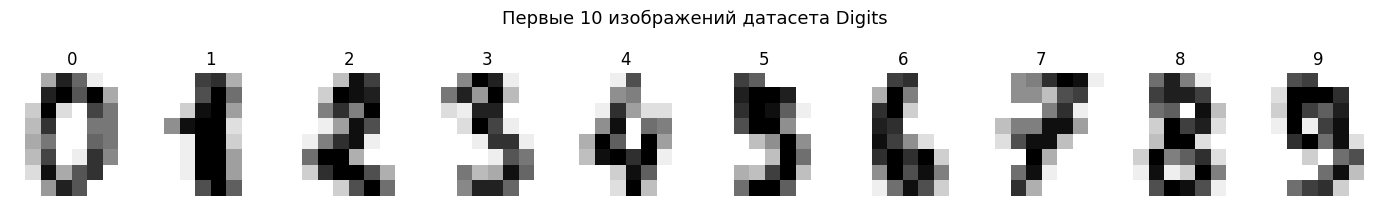

In [4]:
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for ax, image, label in zip(axes, digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap='gray_r')  # отображаем 8x8 изображение
    ax.set_title(str(label), fontsize=12)
    ax.axis('off')
fig.suptitle('Первые 10 изображений датасета Digits', fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

In [5]:

unique, counts = np.unique(y, return_counts=True)
print('Распределение классов:')
print('-' * 25)
for digit, count in zip(unique, counts):
    print(f'  Цифра {digit}: {count} образцов')
print('-' * 25)
print(f'  Итого:  {len(y)} образцов')

Распределение классов:
-------------------------
  Цифра 0: 178 образцов
  Цифра 1: 182 образцов
  Цифра 2: 177 образцов
  Цифра 3: 183 образцов
  Цифра 4: 181 образцов
  Цифра 5: 182 образцов
  Цифра 6: 181 образцов
  Цифра 7: 179 образцов
  Цифра 8: 174 образцов
  Цифра 9: 180 образцов
-------------------------
  Итого:  1797 образцов


## Тепловая карта

Для компактной визуализации строим тепловую карту корреляций по первым 16 пиксельным признакам датасета `Digits`


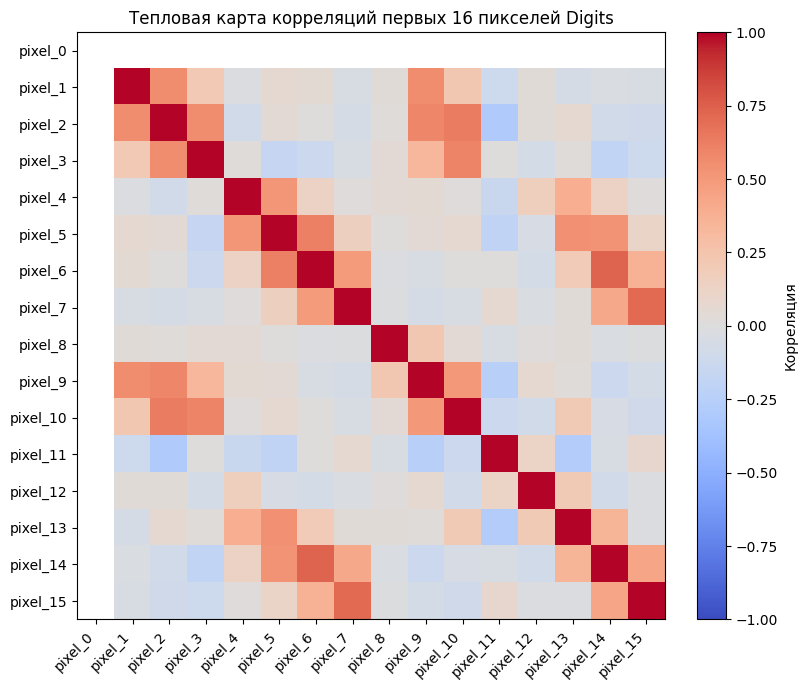

In [6]:
df_digits = pd.DataFrame(X[:, :16], columns=[f'pixel_{i}' for i in range(16)])

corr_matrix = df_digits.corr().round(2)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(16))
ax.set_yticks(range(16))
ax.set_xticklabels(df_digits.columns, rotation=45, ha='right')
ax.set_yticklabels(df_digits.columns)
ax.set_title('Тепловая карта корреляций первых 16 пикселей Digits')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Корреляция')
plt.tight_layout()
plt.show()


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка:  {X_test.shape[0]} объектов')

Обучающая выборка: 1437 объектов
Тестовая выборка:  360 объектов


## Масштабирование

Используем `StandardScaler`.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Среднее после масштабирования (train): {X_train_scaled.mean():.4f}')
print(f'Std после масштабирования  (train): {X_train_scaled.std():.4f}')

Среднее после масштабирования (train): 0.0000
Std после масштабирования  (train): 0.9763


## Обучение MLP

Обучим базовую модель — многослойный перцептрон с двумя скрытыми слоями (128 и 64 нейрона), функцией активации ReLU и оптимизатором Adam.

In [9]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # два скрытых слоя: 128 и 64 нейрона
    activation='relu',             # функция активации ReLU
    solver='adam',                 # оптимизатор Adam
    max_iter=300,                  # максимальное число эпох
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f'Точность (accuracy) на тесте: {acc:.4f}')
print()

Точность (accuracy) на тесте: 0.9694



In [10]:
print('Отчёт классификации:')
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

Отчёт классификации:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        36
           1       0.89      0.94      0.92        36
           2       0.95      1.00      0.97        35
           3       1.00      1.00      1.00        37
           4       0.97      0.97      0.97        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       0.94      0.86      0.90        35
           9       1.00      1.00      1.00        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



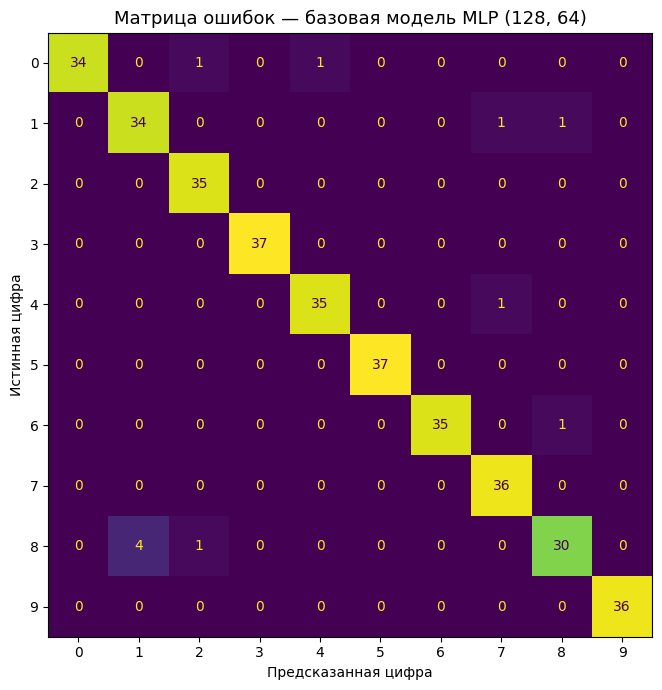

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=digits.target_names,
    colorbar=False,
    ax=ax
)
ax.set_title('Матрица ошибок — базовая модель MLP (128, 64)', fontsize=13)
ax.set_xlabel('Предсказанная цифра')
ax.set_ylabel('Истинная цифра')
plt.tight_layout()
plt.show()

## Влияние архитектуры

Сравним несколько конфигураций скрытых слоёв.

In [12]:
architectures = [
    (64,),
    (128,),
    (128, 64),
    (256, 128, 64)
]

arch_results = []

for hidden_sizes in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=hidden_sizes,
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    arch_results.append({'Архитектура': str(hidden_sizes), 'Точность': acc})

df_arch = pd.DataFrame(arch_results)
df_arch['Точность'] = df_arch['Точность'].map('{:.4f}'.format)
print('Сравнение архитектур:')
print(df_arch.to_string(index=False))

Сравнение архитектур:
   Архитектура Точность
         (64,)   0.9806
        (128,)   0.9778
     (128, 64)   0.9694
(256, 128, 64)   0.9806


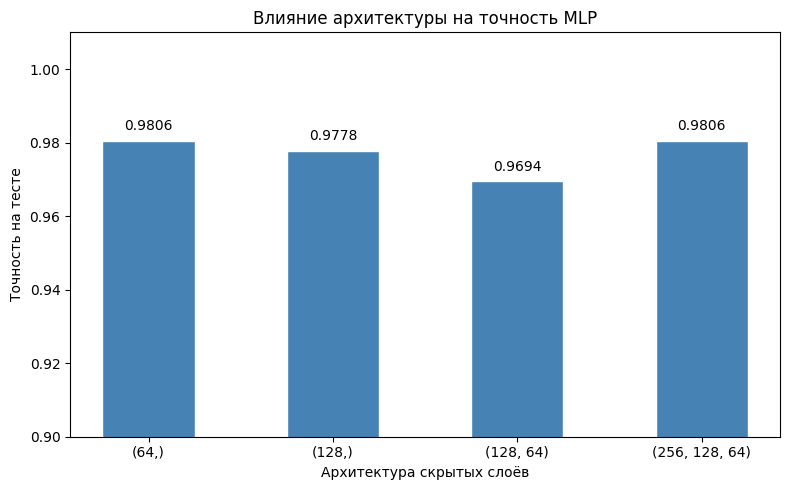

In [13]:
arch_labels = [str(a) for a in architectures]
arch_accs = [float(r['Точность']) for r in arch_results]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(arch_labels, arch_accs, color='steelblue', edgecolor='white', width=0.5)

for bar, acc in zip(bars, arch_accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{acc:.4f}',
        ha='center', va='bottom', fontsize=10
    )

ax.set_ylim(0.9, 1.01)
ax.set_xlabel('Архитектура скрытых слоёв')
ax.set_ylabel('Точность на тесте')
ax.set_title('Влияние архитектуры на точность MLP')
plt.tight_layout()
plt.show()

## Влияние функции активации

Сравним `relu`, `tanh` и `logistic` при фиксированной архитектуре `(128, 64)`.

In [14]:
activations = ['relu', 'tanh', 'logistic']
act_results = []

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation=act,
        solver='adam',
        max_iter=300,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    act_results.append({'Активация': act, 'Точность': acc})

df_act = pd.DataFrame(act_results)
df_act['Точность'] = df_act['Точность'].map('{:.4f}'.format)
print('Сравнение функций активации (архитектура 128, 64):')
print(df_act.to_string(index=False))

Сравнение функций активации (архитектура 128, 64):
Активация Точность
     relu   0.9694
     tanh   0.9694
 logistic   0.9667


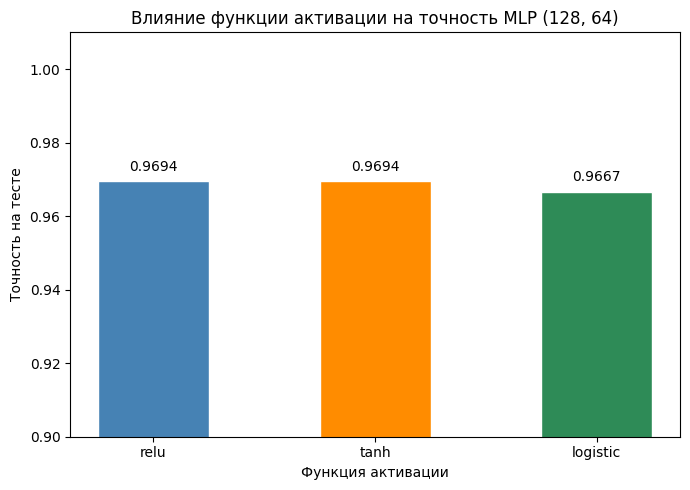

In [15]:
act_accs = [float(r['Точность']) for r in act_results]

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['steelblue', 'darkorange', 'seagreen']
bars = ax.bar(activations, act_accs, color=colors, edgecolor='white', width=0.5)

for bar, acc in zip(bars, act_accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{acc:.4f}',
        ha='center', va='bottom', fontsize=10
    )

ax.set_ylim(0.9, 1.01)
ax.set_xlabel('Функция активации')
ax.set_ylabel('Точность на тесте')
ax.set_title('Влияние функции активации на точность MLP (128, 64)')
plt.tight_layout()
plt.show()

## Кривая обучения

In [16]:
mlp_curve = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)
mlp_curve.fit(X_train_scaled, y_train)

loss_values = mlp_curve.loss_curve_
epochs = range(1, len(loss_values) + 1)

print(f'Число эпох до сходимости: {len(loss_values)}')
print(f'Начальная потеря: {loss_values[0]:.4f}')
print(f'Финальная потеря: {loss_values[-1]:.4f}')

Число эпох до сходимости: 81
Начальная потеря: 2.2397
Финальная потеря: 0.0023


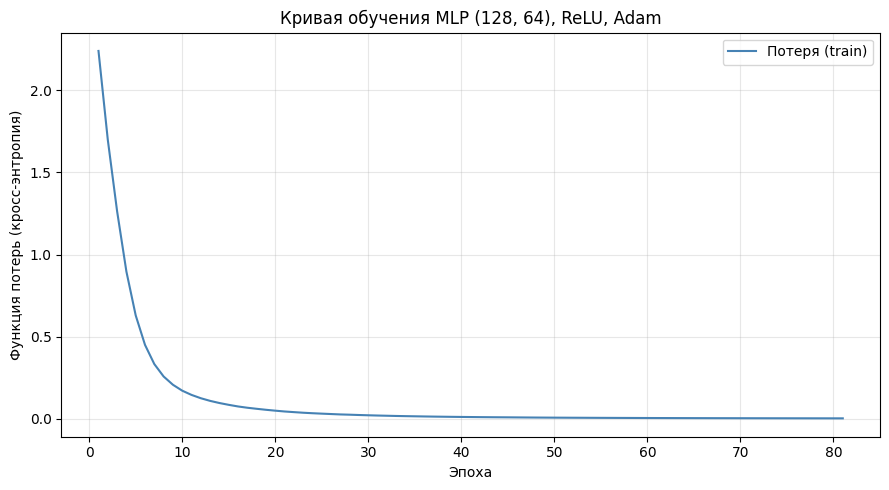

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, loss_values, color='steelblue', linewidth=1.5, label='Потеря (train)')
ax.set_xlabel('Эпоха')
ax.set_ylabel('Функция потерь (кросс-энтропия)')
ax.set_title('Кривая обучения MLP (128, 64), ReLU, Adam')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Влияние масштабирования

Сравним точность MLP с масштабированием и без.

In [18]:

mlp_no_scale = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)
mlp_no_scale.fit(X_train, y_train)
acc_no_scale = accuracy_score(y_test, mlp_no_scale.predict(X_test))

mlp_scaled = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)
mlp_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, mlp_scaled.predict(X_test_scaled))

print('Влияние масштабирования на точность MLP (128, 64):')
print('-' * 45)
print(f'  Без масштабирования: {acc_no_scale:.4f}')
print(f'  С масштабированием: {acc_scaled:.4f}')
print('-' * 45)
print(f'  Прирост точности:   {acc_scaled - acc_no_scale:+.4f}')

Влияние масштабирования на точность MLP (128, 64):
---------------------------------------------
  Без масштабирования: 0.9778
  С масштабированием: 0.9694
---------------------------------------------
  Прирост точности:   -0.0083


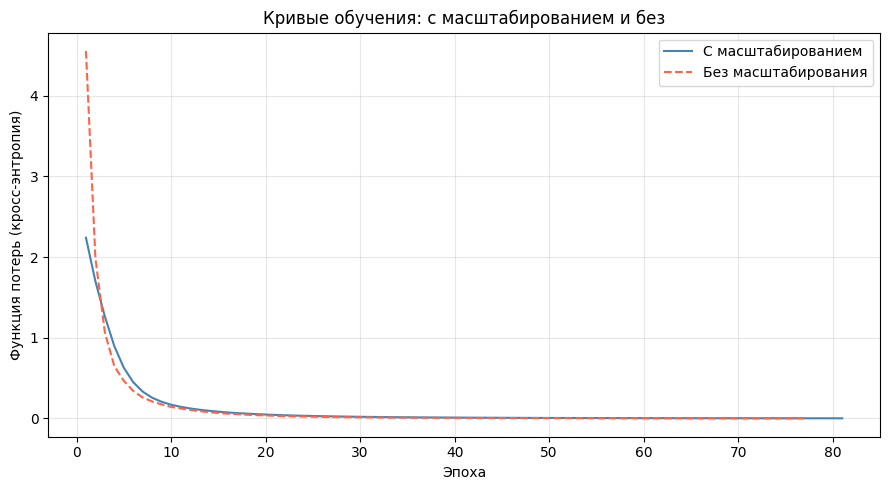

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    range(1, len(mlp_scaled.loss_curve_) + 1),
    mlp_scaled.loss_curve_,
    color='steelblue', linewidth=1.5, label='С масштабированием'
)
ax.plot(
    range(1, len(mlp_no_scale.loss_curve_) + 1),
    mlp_no_scale.loss_curve_,
    color='tomato', linewidth=1.5, linestyle='--', label='Без масштабирования'
)

ax.set_xlabel('Эпоха')
ax.set_ylabel('Функция потерь (кросс-энтропия)')
ax.set_title('Кривые обучения: с масштабированием и без')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Визуализация ошибок

Рассмотрим изображения, на которых модель ошиблась.

In [20]:
y_pred_final = mlp_scaled.predict(X_test_scaled)
error_mask = y_pred_final != y_test

error_indices = np.where(error_mask)[0]
print(f'Число ошибок: {len(error_indices)} из {len(y_test)} ({len(error_indices)/len(y_test)*100:.1f}%)')

Число ошибок: 11 из 360 (3.1%)


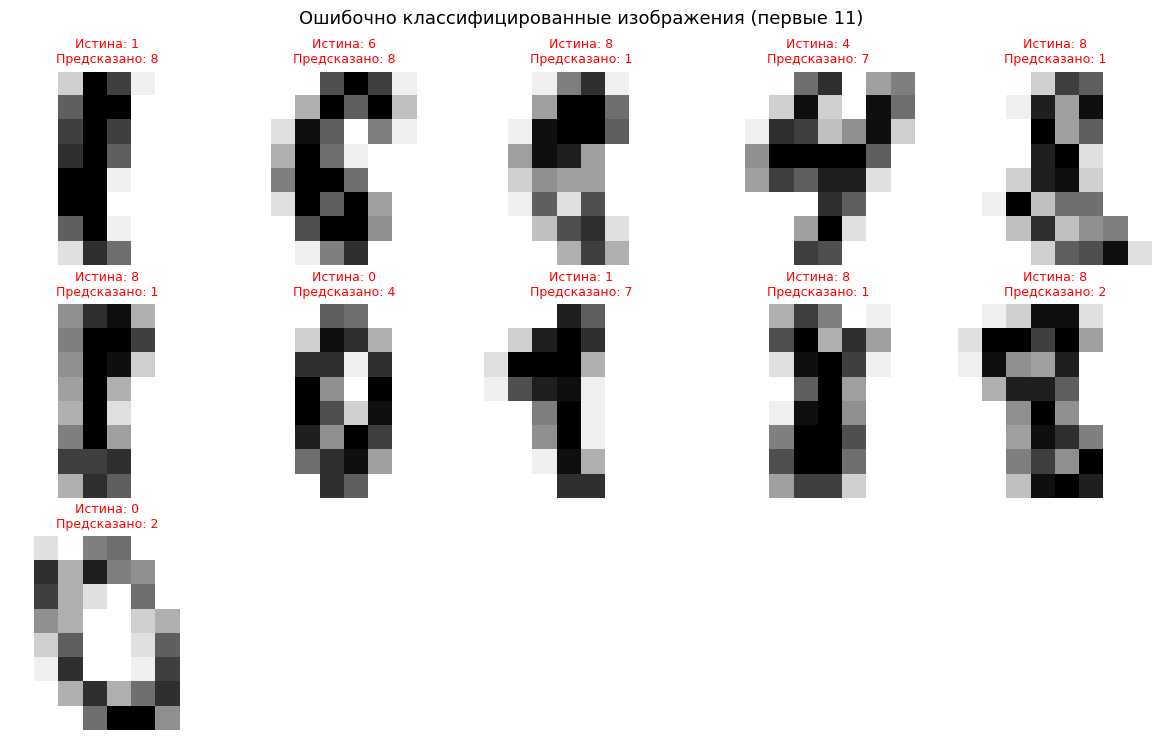

In [21]:
n_show = min(20, len(error_indices))
ncols = 5
nrows = (n_show + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 2.5))
axes = axes.flatten()

for i, idx in enumerate(error_indices[:n_show]):
    image = X_test[idx].reshape(8, 8)  # используем исходные данные для отображения
    axes[i].imshow(image, cmap='gray_r')
    axes[i].set_title(
        f'Истина: {y_test[idx]}\nПредсказано: {y_pred_final[idx]}',
        fontsize=9, color='red'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Ошибочно классифицированные изображения (первые {n_show})', fontsize=13)
plt.tight_layout()
plt.show()